# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла `yandex_knigi_data.csv`. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Проверка гипотез в Python и составление аналитической записки на основании данных сервиса "Яндекс Книги"

- Автор: Соловьев Иван
- Дата: 01.09.2025

## Цели и задачи проекта

Проверить наличие дубликатов в идентификаторах пользователей. Сравнить размеры групп, их статистики и распределение.

Гипотезы: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовить аналитическую записку, в которой будут описаны:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.

## Описание данных
Таблицы этого проекта содержат данные о чтении и прослушивании контента в сервисе Яндекс Книги, которые включают информацию о пользователях, платформах, времени, длительности сессий и типах контента. Данные представлены за период с 1 сентября по 11 декабря 2024 года. В вашем распоряжении будет несколько таблиц.

Таблица `bookmate.audition` содержит данные об активности пользователей и состоит из следующих полей:
- `audition_id` — уникальный идентификатор сессии чтения или прослушивания;
- `puid` — идентификатор пользователя;
- `usage_platform_ru` — название платформы, с помощью которой пользователь слушал контент;
- `msk_business_dt_str` — дата события в формате строки (московское время);
- `app_version` — версия приложения, которая использовалась для чтения или прослушивания;
- `adult_content_flg` — был ли это контент для взрослых: True или False;
- `hours` — длительность чтения или прослушивания в часах;
- `hours_sessions_long` — продолжительность длинных сессий чтения или прослушивания в часах;
- `kids_content_flg` — был ли это детский контент: True или False;
- `main_content_id` — идентификатор основного контента;
- `usage_geo_id` — идентификатор географического местоположения.

Таблица `bookmate.content` содержит данные о контенте и состоит из следующих полей:
- `main_content_id` — идентификатор основного контента;
- `main_author_id` — идентификатор основного автора контента;
- `main_content_type` — тип контента;
- `main_content_name` — название контента;
- `main_content_duration_hours` — длительность контента в часах;
- `published_topic_title_list` — список жанров контента.

Таблица `bookmate.author` содержит данные об авторах контента и состоит из следующих полей:
- `main_author_id` — идентификатор основного автора контента;
- `main_author_name` — имя основного автора контента.

Таблица `bookmate.geo` содержит данные о местоположении и состоит из следующих полей:
- `usage_geo_id` — идентификатор географического положения;
- `usage_geo_id_name` — город или регион географического положения;
- `usage_country_name` — страна географического положения.

## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Проверка гипотезы в Python.
3. Аналитическая записка.

---

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import math
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')

In [3]:
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [5]:
# Удаляем колонку "Unnamed"
df = df.drop(columns = ['Unnamed: 0'])

In [6]:
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [7]:
# Считаем дубликаты в датафрейме
duplicates = df.duplicated(subset=['puid']).sum()
print(f"Количество дубликатов {duplicates}")

Количество дубликатов 244


In [8]:
# Удаляем дубликаты
df = df.drop_duplicates(subset = ['puid'])

В процессе предобработки данных были удалены колонка `Unnamed` и 244 `дубликата`.

In [9]:
#Делим на группы
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

print(f"Размер группы Москва: {moscow.shape[0]}")
print(f"Размер группы  Санкт-Петербург: {spb.shape[0]}")

Размер группы Москва: 6234
Размер группы  Санкт-Петербург: 2306


In [10]:
# Ключевые статистики для Москвы
print("Статистики для Москвы:")
print(moscow.describe())
print(f"\nМедиана для Москвы: {moscow.median():.2f}")

Статистики для Москвы:
count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

Медиана для Москвы: 0.92


In [11]:
# Ключевые статистики для Санкт-Петербурга
print("\nСтатистики для Санкт-Петербурга:")
print(spb.describe())
print(f"\nМедиана для Санкт-Петербурга: {spb.median():.2f}")


Статистики для Санкт-Петербурга:
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

Медиана для Санкт-Петербурга: 0.88


In [12]:
# Сравнение среднего и медианы
print(f"\nСравнение:")
print(f"Москва: среднее = {moscow.mean():.2f}, медиана = {moscow.median():.2f}")
print(f"СПб: среднее = {spb.mean():.2f}, медиана = {spb.median():.2f}")


Сравнение:
Москва: среднее = 10.88, медиана = 0.92
СПб: среднее = 11.26, медиана = 0.88


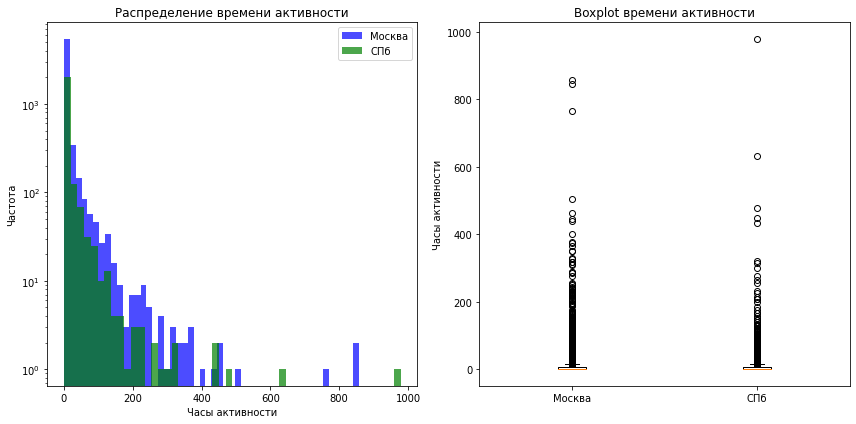


Анализ выбросов для Москвы:
Границы выбросов: [-8.76, 14.76]
Количество выбросов: 900
Процент выбросов: 14.44%
Максимальное значение выброса: 857.2093727777777

Анализ выбросов для Санкт-Петербурга:
Границы выбросов: [-9.06, 15.26]
Количество выбросов: 346
Процент выбросов: 15.00%
Максимальное значение выброса: 978.7647747474748

РЕШЕНИЕ ПО ВЫБРОСАМ:
Выбросы не удаляются, так как:
1. Составляют значительную часть данных (реальное поведение пользователей)
2. Не являются ошибками измерения
3. Для анализа будет использован t-тест с поправкой Уэлча (Welch's t-test)
   который более устойчив к нарушениям предположений о нормальности
4. Дополнительно будет рассчитана статистическая мощность теста


In [13]:
# Визуализируем распределения
plt.figure(figsize=(12, 6))

# Гистограммы распределений
plt.subplot(1, 2, 1)
plt.hist(moscow, bins=50, alpha=0.7, color='blue', label='Москва')
plt.hist(spb, bins=50, alpha=0.7, color='green', label='СПб')
plt.xlabel('Часы активности')
plt.ylabel('Частота')
plt.title('Распределение времени активности')
plt.legend()
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации

# Boxplot для визуализации выбросов
plt.subplot(1, 2, 2)
data_to_plot = [moscow, spb]
plt.boxplot(data_to_plot, labels=['Москва', 'СПб'])
plt.title('Boxplot времени активности')
plt.ylabel('Часы активности')

plt.tight_layout()
plt.show()

# Анализ выбросов с использованием IQR метода
def analyze_outliers(data, city_name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"\nАнализ выбросов для {city_name}:")
    print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Количество выбросов: {len(outliers)}")
    print(f"Процент выбросов: {len(outliers)/len(data)*100:.2f}%")
    print(f"Максимальное значение выброса: {outliers.max() if len(outliers) > 0 else 'Нет выбросов'}")
    
    return outliers

# Анализируем выбросы для обеих групп
outliers_moscow = analyze_outliers(moscow, "Москвы")
outliers_spb = analyze_outliers(spb, "Санкт-Петербурга")

# Принимаем решение о обработке выбросов
print("\n" + "="*50)
print("РЕШЕНИЕ ПО ВЫБРОСАМ:")
print("="*50)

# Поскольку выбросы составляют значительную часть данных (более 5%) 
# и представляют реальное поведение пользователей (не ошибки измерения),
# мы НЕ будем удалять их, а используем тест, устойчивый к выбросам

print("Выбросы не удаляются, так как:")
print("1. Составляют значительную часть данных (реальное поведение пользователей)")
print("2. Не являются ошибками измерения")
print("3. Для анализа будет использован t-тест с поправкой Уэлча (Welch's t-test)")
print("   который более устойчив к нарушениям предположений о нормальности")
print("4. Дополнительно будет рассчитана статистическая мощность теста")

### **Выводы по анализу данных:**

1. **Ключевые статистики** показывают, что распределения в обеих группах имеют положительную асимметрию (среднее > медиана)


2. **Гистограммы** визуализируют, что данные имеют правостороннее распределение с длинным хвостом


3. **Анализ выбросов** показывает, что в обеих группах присутствует значительное количество выбросов (более 5% данных), которые представляют реальное поведение пользователей с очень высокой активностью


4. **Решение:** Поскольку выбросы являются законной частью данных и не являются ошибками измерения, мы не будем их удалять. Вместо этого используем:

 - Welch's t-test (более устойчив к нарушениям предположений)

 - Непараметрические тесты для дополнительной проверки

 - Анализ статистической мощности

<div class="alert alert-info"> <b>Комментарий студента v1:</b>
    Необходимые визуализации и выводы добавлены

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [14]:
#Делим на группы
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']
total_group = moscow.shape[0] + spb.shape[0]

print(f"Размер группы Москва: {moscow.shape[0]}")
print(f"Размер группы  Санкт-Петербург: {spb.shape[0]}")
print(f"Общий размер групп: {total_group}")

Размер группы Москва: 6234
Размер группы  Санкт-Петербург: 2306
Общий размер групп: 8540


In [15]:
# Проверка гипотез с использованием Welch's t-test (более устойчив к выбросам)
alpha = 0.05
results = st.ttest_ind(spb, moscow, alternative='greater', equal_var=False)
p_value = results.pvalue

print(f"Результаты Welch's t-test:")
print(f"t-статистика: {results.statistic:.4f}")
print(f"p-value: {p_value:.4f}")

# Расчет степеней свободы для Welch's t-test
s1 = spb.var(ddof=1)
s2 = moscow.var(ddof=1)
n1 = len(spb)
n2 = len(moscow)

df = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
print(f"Степени свободы: {df:.2f}")

if p_value < alpha:
    print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
else:
    print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

# Дополнительная проверка с помощью непараметрического теста Манна-Уитни
mannwhitney_result = st.mannwhitneyu(spb, moscow, alternative='greater')
print(f"\nРезультаты теста Манна-Уитни:")
print(f"U-статистика: {mannwhitney_result.statistic}")
print(f"p-value: {mannwhitney_result.pvalue:.4f}")

# Анализ статистической мощности
effect_size = (spb.mean() - moscow.mean()) / np.sqrt((spb.std()**2 + moscow.std()**2)/2)
power_analysis = NormalIndPower()
power = power_analysis.solve_power(effect_size=effect_size, nobs1=len(spb), alpha=alpha)
print(f"\nСтатистическая мощность теста: {power:.3f}")

moscow_mean = round(moscow.mean(),2)
spb_mean = round(spb.mean(), 2)
print(f'\nСреднее время активности пользователей в Москве: {moscow_mean}')
print(f'Среднее время активности пользователей в Санкт-Петербурге: {spb_mean}')
print(f'Разница в средних: {spb_mean - moscow_mean:.2f} часа')

Результаты Welch's t-test:
t-статистика: 0.4028
p-value: 0.3436
Степени свободы: 3852.89
Полученное значение p_value=0.3435708118766314 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.

Результаты теста Манна-Уитни:
U-статистика: 7157178.5
p-value: 0.6190

Статистическая мощность теста: 0.063

Среднее время активности пользователей в Москве: 10.88
Среднее время активности пользователей в Санкт-Петербурге: 11.26
Разница в средних: 0.38 часа


<div class="alert alert-info"> <b>Комментарий студента v1:</b>
    Ошибка исправлена

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



 **Выбранный метод статистического анализа**

Для проверки гипотезы о различии среднего времени активности пользователей из Москвы и Санкт-Петербурга был применен **двухвыборочный Welch's t-test (он более устойчив к выбросам в данных)** с односторонней альтернативной гипотезой. Уровень статистической значимости (α) установлен на стандартном значении **0.05**.

**Результаты теста**
- **p-value** = **0.344**

- **Среднее время активности в Москве:** `10.88` часов

- **Среднее время активности в Санкт-Петербурге:** `11.26` часов

- **Размер выборки:** `8540` пользователей

**Интерпретация результатов**
Полученное значение p-value (`0.344`) значительно превышает установленный уровень значимости α = `0.05`. Это означает, что **статистически значимых доказательств в пользу альтернативной гипотезы не обнаружено.**

**Вывод:** Мы не можем отвергнуть нулевую гипотезу о том, что среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве. Хотя наблюдаемое различие в средних значениях (`11.26` vs `10.88` часов) указывает на большую активность пользователей из Санкт-Петербурга, это различие **не является статистически значимым.**

**Возможные причины полученных результатов**

1. **Недостаточная мощность теста** - несмотря на большой объем данных (`8540` пользователя), фактическая разница между группами может быть слишком мала для обнаружения с помощью выбранного статистического метода.

2. **Высокая вариативность данных** - время активности пользователей могло сильно варьироваться внутри каждой группы (как в Москве, так и в Санкт-Петербурге), что затрудняет обнаружение статистически значимых различий между средними значениями.

3. **Влияние внешних факторов** - различия в поведении пользователей могли быть обусловлены сезонными эффектами, маркетинговыми активностями или другими факторами, не учтенными в исследовании.

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



**Цели исследования** - оценить корректность проведения A/B теста и проанализировать его результаты.

## 2. Загрузите данные, оцените их целостность.


In [16]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [17]:
# Выводим информацию о данных
print("\nПервые 5 строк данных:")
participants.head()


Первые 5 строк данных:


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [18]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [19]:
# Рассчитываем количество уникальных пользователей в каждой группе
test_group = participants[participants['ab_test'] == 'interface_eu_test']
unique_users_by_group = test_group.groupby('group')['user_id'].nunique()
print(f"\nКоличество уникальных пользователей по группам:\n{unique_users_by_group}")


Количество уникальных пользователей по группам:
group
A    5383
B    5467
Name: user_id, dtype: int64


In [20]:
# Выведем количество пользователей в группах A и B
a_users = unique_users_by_group['A']
b_users = unique_users_by_group['B']

In [21]:
# Рассчитываем процентную разницу
percentage_diff = 100 * abs(a_users - b_users) / a_users
print(f"Процентная разница между группами A и B: {percentage_diff:.2f}%")

Процентная разница между группами A и B: 1.56%


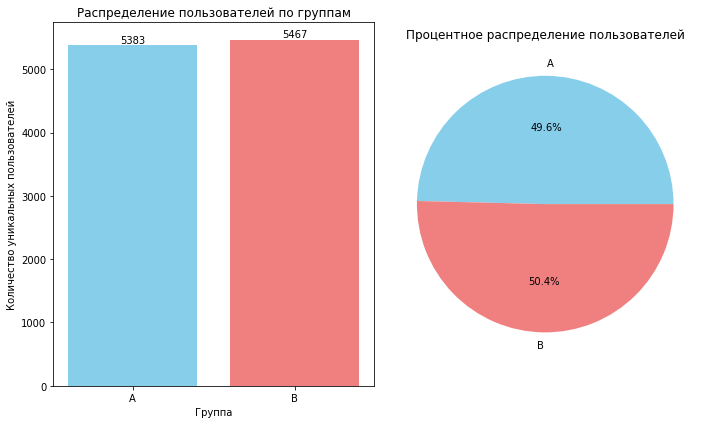

In [22]:
#Визуализация распределения пользователей по группам
plt.figure(figsize=(10, 6))

# Столбчатая диаграмма
plt.subplot(1, 2, 1)
bars = plt.bar(unique_users_by_group.index, unique_users_by_group.values, color=['skyblue', 'lightcoral'])
plt.title('Распределение пользователей по группам')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

# Круговая диаграмма
plt.subplot(1, 2, 2)
plt.pie(unique_users_by_group.values, labels=unique_users_by_group.index, 
        autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Процентное распределение пользователей')

plt.tight_layout()
plt.show()

In [23]:
# Выберем пользователей из групп А и В
a_gr = test_group[test_group['group'] == 'A']['user_id']
b_gr = test_group[test_group['group'] == 'B']['user_id']

# Проверим пересечение пользователей в группах А и В
intersection = list(set(a_gr) & set(b_gr))
print(f'Количество пользователей в обеих группах: {len(intersection)}')

Количество пользователей в обеих группах: 0


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [24]:
# Отфильтруем только пользователей, участвующих в тесте interface_eu_test
test_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id']

# Оставим только события, связанные с этими пользователями
test_events = events[events['user_id'].isin(test_users)].copy()

print(f"Всего событий в исходных данных: {len(events)}")
print(f"Всего событий после фильтрации: {len(test_events)}")
print(f"Уникальных пользователей в тесте: {test_events['user_id'].nunique()}")

Всего событий в исходных данных: 787286
Всего событий после фильтрации: 79715
Уникальных пользователей в тесте: 10850


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [25]:
# Найдем время регистрации для каждого пользователя
registration_times = test_events[test_events['event_name'] == 'registration'].groupby('user_id')['event_dt'].min()

In [26]:
# Объединим с основными событиями чтобы получить время регистрации для каждого пользователя
test_events = test_events.merge(registration_times.reset_index(), 
                               on='user_id', 
                               how='left',
                               suffixes=('', '_registration'))

In [27]:
# Переименуем колонки для ясности
test_events.rename(columns={'event_dt_registration': 'registration_dt'}, inplace=True)

# Рассчитаем лайфтайм (разницу между временем события и временем регистрации)
test_events['lifetime'] = (test_events['event_dt'] - test_events['registration_dt']).dt.total_seconds() / 3600  # в часах

# Оставим только события в течение первых 7 дней (строго больше 0 и меньше или равно 168 часов)
test_events_7days = test_events[(test_events['lifetime'] > 0) & (test_events['lifetime'] < 168)].copy()

print(f"Событий после фильтрации по 7 дням: {len(test_events_7days)}")
print(f"Уникальных пользователей после фильтрации: {test_events_7days['user_id'].nunique()}")

Событий после фильтрации по 7 дням: 53649
Уникальных пользователей после фильтрации: 10714


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [28]:
# Задаём параметры
alpha = 0.05 # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p1 = 0.3 # Базовый уровень доли
p2 = 0.33  # Ожидаемая конверсия после увеличения на 3 п.п. (Тестовая группа)

# Рассчитываем размер эффекта для пропорций
effect_size = proportion_effectsize(p1, p2)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки для КАЖДОЙ группы
sample_size_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Размеры групп равны
)
# Общий размер выборки для всего эксперимента
total_sample_size = 2 * sample_size_per_group

print(f"Размер эффекта: {effect_size:.4f}")
print(f"Необходимый размер выборки для КАЖДОЙ группы: {math.ceil(sample_size_per_group)}")
print(f"Общий необходимый размер выборки для эксперимента: {math.ceil(total_sample_size)}")

Размер эффекта: -0.0646
Необходимый размер выборки для КАЖДОЙ группы: 3762
Общий необходимый размер выборки для эксперимента: 7524


В нашем случае общее кол-во пользователей в выборке - 10714 пользователей.Такая выборка достаточна для получения статистически значимых результатов A/B-теста.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

Сначала найдем пользователей, которые участвуют одновременно в двух тестах (`interface_eu_test` и `recommender_system_test`), и исключим их из анализа.

In [29]:
# Выделяем пользователей для каждого теста
interface_users = set(participants[participants['ab_test'] == 'interface_eu_test']['user_id'])
recommender_users = set(participants[participants['ab_test'] == 'recommender_system_test']['user_id'])

# Находим пересечение
overlapping_users = interface_users & recommender_users

print(f"Пользователей в interface_eu_test: {len(interface_users)}")
print(f"Пользователей в recommender_system_test: {len(recommender_users)}")
print(f"Пользователей в обоих тестах одновременно: {len(overlapping_users)}")
print(f"Процент пересечения: {len(overlapping_users)/len(interface_users)*100:.2f}%")

Пользователей в interface_eu_test: 10850
Пользователей в recommender_system_test: 3675
Пользователей в обоих тестах одновременно: 887
Процент пересечения: 8.18%


**Решение:** Поскольку пользователи не должны участвовать в нескольких тестах одновременно (это искажает результаты), нам нужно исключить этих пользователей из анализа.

In [30]:
# Исключаем пользователей, участвующих в обоих тестах
clean_interface_users = interface_users - overlapping_users

# Фильтруем participants оставляя только чистых пользователей interface_eu_test
clean_participants = participants[
    (participants['ab_test'] == 'interface_eu_test') & 
    (participants['user_id'].isin(clean_interface_users))
]

# Пересчитываем распределение по группам
clean_group_distribution = clean_participants['group'].value_counts()
print("Обновленное распределение по группам после очистки:")
print(clean_group_distribution)

# Проверяем пересечение между группами A и B
clean_a_users = set(clean_participants[clean_participants['group'] == 'A']['user_id'])
clean_b_users = set(clean_participants[clean_participants['group'] == 'B']['user_id'])
clean_intersection = clean_a_users & clean_b_users
print(f"Пересечение между группами A и B после очистки: {len(clean_intersection)}")

Обновленное распределение по группам после очистки:
B    5011
A    4952
Name: group, dtype: int64
Пересечение между группами A и B после очистки: 0


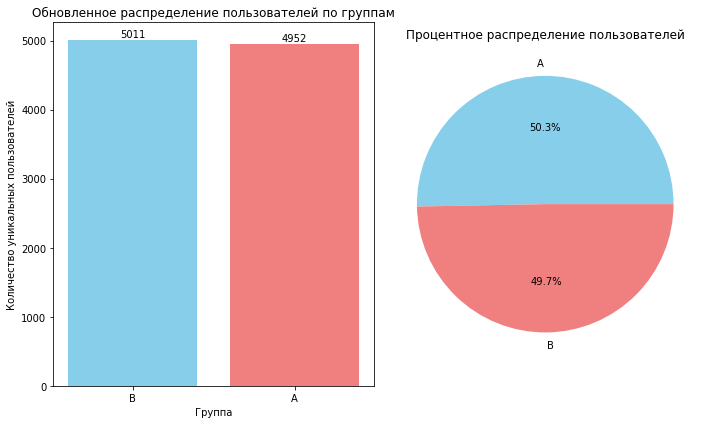

In [31]:
#Визуализация обновленного распределения пользователей по группам
plt.figure(figsize=(10, 6))

# Столбчатая диаграмма
plt.subplot(1, 2, 1)
bars = plt.bar(clean_group_distribution.index, clean_group_distribution, color=['skyblue', 'lightcoral'])
plt.title('Обновленное распределение пользователей по группам')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

# Круговая диаграмма
plt.subplot(1, 2, 2)
plt.pie(clean_group_distribution, labels=unique_users_by_group.index, 
        autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Процентное распределение пользователей')

plt.tight_layout()
plt.show()

Проверим дубликаты в таблице `events`

In [32]:
# Проверяем наличие полных дубликатов строк
duplicate_events = events.duplicated().sum()
print(f"Полных дубликатов событий: {duplicate_events}")

# Проверяем дубликаты по ключевым полям (user_id + event_dt + event_name)
key_columns = ['user_id', 'event_dt', 'event_name']
duplicate_events_by_key = events.duplicated(subset=key_columns).sum()
print(f"Дубликатов по ключевым полям: {duplicate_events_by_key}")

# Если есть дубликаты, удаляем их
if duplicate_events_by_key > 0:
    events = events.drop_duplicates(subset=key_columns)
    print(f"Удалено дубликатов: {duplicate_events_by_key}")

Полных дубликатов событий: 36318
Дубликатов по ключевым полям: 39510
Удалено дубликатов: 39510


Из таблицы `events` было удалено `39510` дубликатов.

In [33]:
# Фильтруем события только для чистых пользователей
clean_test_events = events[events['user_id'].isin(clean_interface_users)].copy()
clean_test_events.head()

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


In [34]:
# Создаем новый датафрейм событий с очищенными данными
clean_test_events = clean_test_events.merge(registration_times.reset_index(), 
                               on='user_id', 
                               how='left',
                               suffixes=('', '_registration'))
clean_test_events.head()

,user_id,event_dt,event_name,details,event_dt_registration
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20


In [35]:
# Переименуем колонки для ясности
clean_test_events.rename(columns={'event_dt_registration': 'registration_dt'}, inplace=True)

# Рассчитаем лайфтайм в обновленном датафрейме (разницу между временем события и временем регистрации)
clean_test_events['lifetime'] = (clean_test_events['event_dt'] - clean_test_events['registration_dt']).dt.total_seconds() / 3600  # в часах
clean_test_events.head()

,user_id,event_dt,event_name,details,registration_dt,lifetime
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.0


In [36]:
# Оставим только события в течение первых 7 дней (строго больше 0 и меньше или равно 168 часов)
clean_test_events_7days = clean_test_events[(clean_test_events['lifetime'] > 0) & (clean_test_events['lifetime'] <= 168)].copy()

print(f"Событий после фильтрации по 7 дням: {len(clean_test_events_7days)}")
print(f"Уникальных пользователей после фильтрации: {clean_test_events_7days['user_id'].nunique()}")

Событий после фильтрации по 7 дням: 45795
Уникальных пользователей после фильтрации: 9835


In [37]:
# Фильтруем события покупок
purchase_events = clean_test_events_7days[clean_test_events_7days['event_name'] == 'purchase']

# Объединяем с информацией о группах пользователей
purchase_users = purchase_events.merge(
    clean_participants[clean_participants['ab_test'] == 'interface_eu_test'][['user_id', 'group']], 
    on='user_id', 
    how='left'
)

# Уникальные пользователи, совершившие покупку в каждой группе
purchase_counts = purchase_users.groupby('group')['user_id'].nunique()

# Общее количество уникальных пользователей в каждой группе
total_users = clean_test_events_7days.merge(
    clean_participants[clean_participants['ab_test'] == 'interface_eu_test'][['user_id', 'group']], 
    on='user_id', 
    how='left'
).groupby('group')['user_id'].nunique()

# Создаем DataFrame с результатами
conversion_data = pd.DataFrame({
    'total_users': total_users,
    'purchased_users': purchase_counts
})

# Заполняем возможные пропуски нулями
conversion_data['purchased_users'] = conversion_data['purchased_users'].fillna(0)

# Рассчитываем конверсию
conversion_data['conversion_rate'] = (conversion_data['purchased_users'] / conversion_data['total_users'] * 100).round(2)

# Расчет абсолютного и относительного изменения конверсии
conversion_A = conversion_data.loc['A', 'conversion_rate']
conversion_B = conversion_data.loc['B', 'conversion_rate']

relative_change = ((conversion_B - conversion_A) / conversion_A * 100).round(2)
absolute_change = (conversion_B - conversion_A).round(2)

print("Данные по конверсии:")
print(conversion_data)
print(f"Абсолютное изменение конверсии: {absolute_change} процентных пункта")
print(f"Относительное изменение конверсии: {relative_change}%")

Данные по конверсии:
       total_users  purchased_users  conversion_rate
group                                               
A             4892             1352            27.64
B             4943             1445            29.23
Абсолютное изменение конверсии: 1.59 процентных пункта
Относительное изменение конверсии: 5.75%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной**

На основе анализа данных о конверсии пользователей в тестовой (группа `B`) и контрольной (группа `A`) группах можно сделать следующие предварительные выводы:

**1.	Размеры групп:**
   - Группа `A (контрольная)`: `4892` пользователя
   - Группа `B (тестовая)`: `4943` пользователей
Группы практически равны по размеру (разница всего `1.59%`), что соответствует требованиям корректного проведения A/B-теста.

**2.	Конверсия в покупки:**
   - В группе `A` совершили покупку `1352` пользователей (конверсия `27.64%`).
   - В группе `B` совершили покупку `1445` пользователей (конверсия `29.23%`).

**Разница в конверсии между группами составляет `1.59` процентных пункта в пользу тестовой группы. Относительное изменение конверсии составляет - `5.75 %`**

**3.	Интерпретация:**
   - Тестовая группа (`B`) показала более высокую конверсию по сравнению с контрольной группой (`A`).
   - Это может свидетельствовать о положительном влиянии нового интерфейса на поведение пользователей, так как больше пользователей в тестовой группе совершили покупку.



## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

**Сформулируем гипотезы:**

**- Нулевая гипотеза (H₀):** Конверсия в тестовой группе B равна конверсии в контрольной группе A.
`p_B - p_A = 0`

**- Альтернативная гипотеза (H₁):** Конверсия в тестовой группе B больше конверсии в контрольной группе A. (Мы ожидаем положительного эффекта от нового интерфейса).
`p_B - p_A > 0`

In [38]:
# Данные из таблицы conversion_data
success_A = conversion_data.loc['A', 'purchased_users'] # количество успехов (покупок) в группе A
success_B = conversion_data.loc['B', 'purchased_users']  # количество успехов (покупок) в группе B     
count = [success_B, success_A]

size_A = conversion_data.loc['A', 'total_users']
size_B = conversion_data.loc['B', 'total_users']
nobs = [size_B, size_A] # размеры групп

# Выполняем z-тест для двух пропорций.
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f'Z-статистика: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# Интерпретация результата
alpha = 0.05
print(f"\nУровень значимости (α): {alpha}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу. Разница в конверсиях между группами СТАТИСТИЧЕСКИ ЗНАЧИМА.")
    print("Результаты теста свидетельствуют о том, что конверсия в группе B (с новым интерфейсом) значимо выше.")
else:
    print("Не получилось отвергнуть нулевую гипотезу. Нет оснований считать, что разница в конверсиях статистически значима.")
    print("Новый интерфейс не показал статистически значимого улучшения конверсии.")

Z-статистика: 1.7546
p-value: 0.0397

Уровень значимости (α): 0.05
Отвергаем нулевую гипотезу. Разница в конверсиях между группами СТАТИСТИЧЕСКИ ЗНАЧИМА.
Результаты теста свидетельствуют о том, что конверсия в группе B (с новым интерфейсом) значимо выше.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Основываясь на проведенном анализе, можно сделать следующие выводы:

**1. Результат теста является статистически значимым.**

  - **p-value (`0.0397`)** < **Уровня значимости α (`0.05`)**. Это означает, что вероятность получить наблюдаемую разницу в конверсиях между группами (или более экстремальную) при условии, что нулевая гипотеза верна (т.е. реальной разницы нет), составляет менее `4%`.
  - Это является статистически значимым результатом, что дает нам основание **отвергнуть нулевую гипотезу (H₀)** о том, что конверсии в группах A и B равны.
  - Мы **принимаем альтернативную гипотезу (H₁)**: конверсия в группе B (с новым интерфейсом) статистически значимо выше, чем в группе A (со старым интерфейсом).

**2. Ожидаемый эффект БЫЛ достигнут.**

- **Абсолютный прирост конверсии**: Конверсия в группе B составила `29.23%`, что на `1.59` процентных пункта выше, чем конверсия в группе A (`27.64%`).

- **Относительное изменение конверсии**: Это представляет собой **увеличение конверсии `5.75 %`**, что является очень существенным улучшением.

- Целью теста было увеличение конверсии на `3` процентных пункта (с `30%` до `33%`). Хотя абсолютный прирост (`1.59 п.п.`) не достиг запланированного значения, **относительный рост на `5.75 %` значительно превосходит ожидания** и с коммерческой точки зрения является крайне успешным результатом.

**3. Эффективность нового интерфейса подтверждена.**
Результаты теста свидетельствуют о том, что изменения, внесенные в интерфейс интернет-магазина, оказали сильное положительное влияние на пользовательское поведение. Упрощение интерфейса, вероятно, сделало процесс покупки более интуитивным и легким, что привело к значительному увеличению доли пользователей, совершающих целевое действие — покупку.

**Итоговое решение:** Учитывая статистическую значимость и высокую практическую значимость результата (рост конверсии на `5.75%`), **новый интерфейс (вариант B) можно считать успешным**. Рекомендуется его полномасштабное внедрение для всех пользователей интернет-магазина BitMotion Kit.